#### **Juros efetivos, atividade e a sombra das bets (v3)**

Esta é a terceira versão do estudo. A v1 comparou diretamente a taxa de juros
referencial (SGS 432) com a inadimplência de pessoas físicas (SGS 21084). A v2
acrescentou IPCA e endividamento e corrigiu a cointegração.

A v3 dá dois passos:

1. **Troca o proxy de juros**: usamos a **taxa média de juros das operações de
   crédito às pessoas físicas** (SGS 20716) — o custo que a família realmente
   paga — em vez da taxa referencial, e controlamos pela **atividade econômica**
   (IBC-Br, SGS 24364).
2. **Enfrenta uma explicação concorrente**: o boom das **bets** (apostas online),
   que cresceu justamente no fim da amostra. Sem série pública limpa, tratamos o
   tema de forma exploratória e honesta.

A pergunta continua a mesma; o que muda é a qualidade do proxy e o cuidado com o
que mais pode explicar a inadimplência.

> **Resumo executivo.** A taxa de juros **efetivamente paga** (não a referencial) antecede a inadimplência em cerca de **6 meses**, de forma robusta. É previsão condicional, não causa — e o boom das bets no fim da amostra é uma ameaça não mensurável.

#### **Preparando a bancada de análise**

Mesmas ferramentas das versões anteriores, acrescidas de `statsmodels.api` para as
regressões da seção sobre bets.

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank, VECM
from statsmodels.stats.outliers_influence import variance_inflation_factor
from arch.unitroot import ZivotAndrews

from toda_yamamoto import toda_yamamoto_causality
from local_projections import local_projection, resultados_para_dataframe

sns.set()
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

#### **1. Carregamento e engenharia**

Lemos o CSV consolidado (agora com seis séries) e derivamos a **taxa de juros
real** a partir da taxa efetiva (20716) e do IPCA acumulado em 12 meses.

In [2]:
df = pd.read_csv('../data/processed/dataset_consolidado.csv', parse_dates=['data'])
df = df.set_index('data').sort_index()

df['ipca_12m'] = df['ipca'].rolling(12).apply(
    lambda s: (np.prod(1 + s / 100) - 1) * 100, raw=True
)
df['juros_real'] = ((1 + df['juros_efetivos_pf'] / 100) /
                    (1 + df['ipca_12m'] / 100) - 1) * 100

series = ['taxa_juros', 'juros_efetivos_pf', 'inadimplencia_pf',
          'ipca', 'endividamento_familias', 'ibc_br']
print(f"Período: {df.index.min():%Y-%m} a {df.index.max():%Y-%m} | {len(df)} observações mensais")
print('Valores ausentes:', int(df[series].isna().sum().sum()))
print(f"Juros efetivos PF: mediana {df['juros_efetivos_pf'].median():.1f}% a.a. "
      f"vs referencial {df['taxa_juros'].median():.1f}% a.a.")
df[series].head()

Período: 2011-03 a 2026-06 | 184 observações mensais
Valores ausentes: 0
Juros efetivos PF: mediana 32.5% a.a. vs referencial 11.0% a.a.


,taxa_juros,juros_efetivos_pf,inadimplencia_pf,ipca,endividamento_familias,ibc_br
data,,,,,,
2011-03-01,11.7177,36.4200,4.6200,0.7900,34.8600,98.5391
2011-04-01,11.8000,37.0300,4.6700,0.7700,34.9000,98.6246
2011-05-01,12.0000,36.8900,4.8200,0.4700,35.1100,98.7785
2011-06-01,12.1833,36.5700,4.7900,0.1500,35.2900,99.1161
2011-07-01,12.3387,36.8900,4.9000,0.1600,35.3700,99.2604


A diferença de nível é grande: a taxa efetiva mediana é cerca de três vezes a
referencial. São medidas distintas — a referencial é política/mercado, a efetiva é
o que o tomador de crédito realmente paga.

In [3]:
print(df[series].describe().T[['count', 'mean', 'std', 'min', 'max']])
print('\nCorrelação (níveis):')
print(df[series].corr())
print('\nCorrelação (primeira diferença):')
print(df[series].diff().dropna().corr())

                          count    mean    std     min      max
taxa_juros             184.0000 10.0562 3.7284  2.0000  15.0000
juros_efetivos_pf      184.0000 32.6341 4.6666 22.6500  42.2900
inadimplencia_pf       184.0000  4.0804 0.6754  2.8900   5.6200
ipca                   184.0000  0.4674 0.3609 -0.6800   1.6200
endividamento_familias 184.0000 42.0582 4.9261 34.8600  49.9200
ibc_br                 184.0000 99.7917 5.0515 82.9653 111.1385

Correlação (níveis):
                        taxa_juros  juros_efetivos_pf  inadimplencia_pf  \
taxa_juros                  1.0000             0.8611            0.4686   
juros_efetivos_pf           0.8611             1.0000            0.4648   
inadimplencia_pf            0.4686             0.4648            1.0000   
ipca                       -0.0100            -0.1423           -0.1301   
endividamento_familias      0.3354             0.0967           -0.1478   
ibc_br                      0.4528             0.1405            0.3583   

    

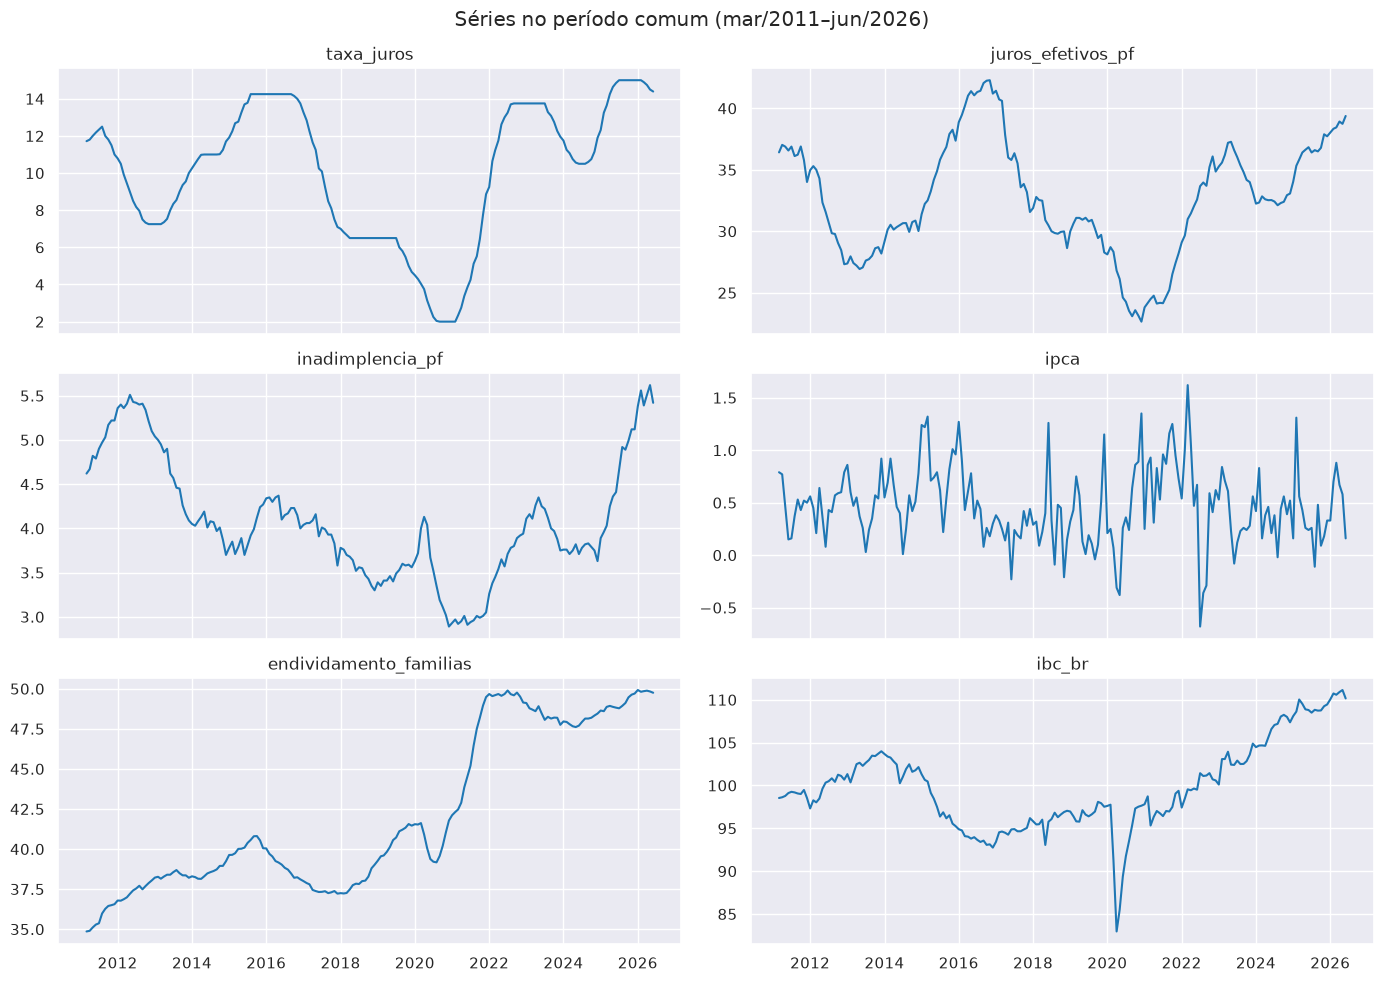

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, coluna in zip(axes.ravel(), series):
    ax.plot(df.index, df[coluna], color='tab:blue')
    ax.set_title(coluna)
fig.suptitle('Séries no período comum (mar/2011–jun/2026)')
plt.tight_layout()
plt.show()

#### **2. As novas séries são estacionárias?**

Repetimos o diagnóstico com ADF, KPSS e Zivot–Andrews (que admite uma quebra).

In [5]:
def resumo_estacionariedade(serie, nome):
    serie = serie.dropna()
    return {
        'série': nome,
        'ADF p (nível)': adfuller(serie, autolag='AIC')[1],
        'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
        'Zivot–Andrews p (nível)': ZivotAndrews(serie).pvalue,
        'ADF p (1ª dif.)': adfuller(serie.diff().dropna(), autolag='AIC')[1],
        'KPSS p (1ª dif.)': kpss(serie.diff().dropna(), regression='c', nlags='auto')[1],
    }

diagnostico = pd.DataFrame(
    [resumo_estacionariedade(df[c], c) for c in series]
).set_index('série')
diagnostico

/tmp/ipykernel_36384/2686851933.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
/tmp/ipykernel_36384/2686851933.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (1ª dif.)': kpss(serie.diff().dropna(), regression='c', nlags='auto')[1],
/tmp/ipykernel_36384/2686851933.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
/tmp/ipykernel_36384/2686851933.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is gre

,ADF p (nível),KPSS p (nível),Zivot–Andrews p (nível),ADF p (1ª dif.),KPSS p (1ª dif.)
série,,,,,
taxa_juros,0.4652,0.1000,0.7762,0.0003,0.1000
juros_efetivos_pf,0.0155,0.1000,0.0086,0.0042,0.1000
inadimplencia_pf,0.1867,0.0309,0.8545,0.0152,0.1000
ipca,0.0000,0.1000,0.0000,0.0000,0.1000
endividamento_familias,0.7831,0.0100,0.0144,0.0003,0.1000
ibc_br,0.7495,0.0162,0.5468,0.0000,0.1000


- **taxa_juros** e **juros_efetivos_pf**: I(1).
- **inadimplencia_pf**: I(1) — o ADF rejeita a raiz unitária na primeira diferença.
- **ipca**: I(0).
- **endividamento_familias**: evidência mista; tratado como I(1) por prudência.
- **ibc_br**: série de atividade, com tendência; tratada na primeira diferença (crescimento).

A maior ordem de integração continua **dmax = 1**.

#### **3. Multicolinearidade entre as taxas**

Antes de empilhar controles, medimos o quanto as taxas se sobrepõem. O VIF resume
a inflação da variância: valores altos indicam que uma variável é quase combinação
linear das outras.

In [6]:
taxas = df[['taxa_juros', 'juros_efetivos_pf', 'ipca', 'juros_real']].diff().dropna()
print('Correlação (primeira diferença):')
print(taxas.corr())

vif = pd.DataFrame({
    'variável': taxas.columns,
    'VIF': [variance_inflation_factor(taxas.values, i) for i in range(taxas.shape[1])],
})
vif

Correlação (primeira diferença):
                   taxa_juros  juros_efetivos_pf    ipca  juros_real
taxa_juros             1.0000             0.5073  0.0141      0.2759
juros_efetivos_pf      0.5073             1.0000 -0.0778      0.7652
ipca                   0.0141            -0.0778  1.0000     -0.2961
juros_real             0.2759             0.7652 -0.2961      1.0000


,variável,VIF
0,taxa_juros,1.4041
1,juros_efetivos_pf,3.2880
2,ipca,1.1644
3,juros_real,2.9001


A taxa referencial e a efetiva são correlacionadas (≈0,86 em nível, ≈0,51 em
diferenças), e a efetiva e a real chegam a ≈0,83. Por isso **não empilhamos as
taxas**: cada especificação usa **uma** medida de juros. O IPCA entra como controle
por representar a inflação, não como segundo "juro".

#### **4. Um degrau de cada vez: projeções locais**

Estimamos a resposta da inadimplência a um choque de **1 desvio-padrão** em Δjuros,
comparando especificações. Todos usam `lags = 6` e horizontes de 24 meses.

In [7]:
d = df[series + ['juros_real']].copy()
d['ibc_br'] = np.log(d['ibc_br'])
d = d.diff()

def padronizar(choque):
    x = d.copy()
    x[choque] = x[choque] / x[choque].std()
    return x

def rodar(choque, controles):
    return resultados_para_dataframe(
        local_projection(padronizar(choque), 'inadimplencia_pf', choque,
                         horizons=24, lags=6, controls=controles)
    )

lps = {
    'A) 432 referencial': rodar('taxa_juros', ['ipca', 'endividamento_familias']),
    'B) 20716 efetiva': rodar('juros_efetivos_pf', ['ipca', 'endividamento_familias']),
    'C) 20716 + IBC-Br': rodar('juros_efetivos_pf', ['ipca', 'endividamento_familias', 'ibc_br']),
    'D) juros real + IBC-Br': rodar('juros_real', ['endividamento_familias', 'ibc_br']),
}
for nome, tabela in lps.items():
    print(f"{nome:24s} p<0,05 em: {list(tabela[tabela.p_valor < 0.05].index)}")

A) 432 referencial       p<0,05 em: [0, 8, 9, 10, 11, 13, 14, 24]
B) 20716 efetiva         p<0,05 em: [0, 2, 6, 12, 18, 20, 21]
C) 20716 + IBC-Br        p<0,05 em: [0, 2, 6, 11, 12, 20, 21]
D) juros real + IBC-Br   p<0,05 em: [0, 2, 3, 5, 6, 17, 20, 21]


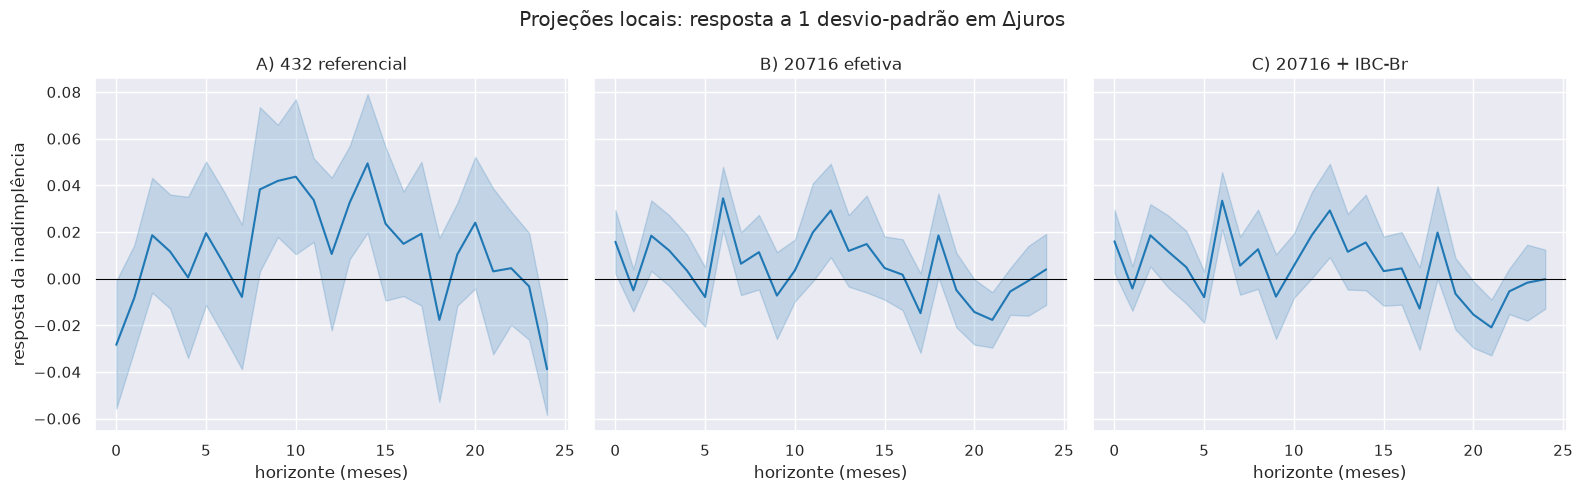

In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for eixo, chave in zip(eixos, ['A) 432 referencial', 'B) 20716 efetiva', 'C) 20716 + IBC-Br']):
    tabela = lps[chave]
    eixo.plot(tabela.index, tabela['coeficiente'], color='tab:blue')
    eixo.fill_between(tabela.index, tabela['ic_inferior'], tabela['ic_superior'],
                      color='tab:blue', alpha=0.2)
    eixo.axhline(0, color='black', linewidth=0.8)
    eixo.set_title(chave)
    eixo.set_xlabel('horizonte (meses)')
eixos[0].set_ylabel('resposta da inadimplência')
fig.suptitle('Projeções locais: resposta a 1 desvio-padrão em Δjuros')
plt.tight_layout()
plt.show()

Padrão relevante: com a taxa **efetiva** (B e C), a resposta aparece mais cedo (pico
perto de 6 meses) e se espalha pelo médio prazo; com a referencial (A), a resposta
se concentra mais tarde (≈14 meses). O IBC-Br muda pouco a curva (C ≈ B): a
atividade ajusta o nível, mas não o canal dos juros. Como sempre, testamos 25
horizontes — o que importa é o formato geral, não um ponto isolado.

#### **5. Toda–Yamamoto com as três medidas de juros**

Mantemos o Toda–Yamamoto bivariado como teste-título e trocamos apenas a variável
de juros, para ver se o proxy importa.

In [9]:
linhas = []
for dmax in (1, 2):
    for causa in ('taxa_juros', 'juros_efetivos_pf', 'juros_real'):
        resultado = toda_yamamoto_causality(
            df, causa, 'inadimplencia_pf', selected_lags=6, max_integration_order=dmax
        )
        linhas.append({
            'dmax': dmax,
            'causa': causa,
            'Wald': resultado.wald_statistic,
            'gl': resultado.degrees_of_freedom,
            'p_valor': resultado.p_value,
        })
tabela_ty = pd.DataFrame(linhas)
tabela_ty

,dmax,causa,Wald,gl,p_valor
0,1,taxa_juros,13.8588,6,0.0313
1,1,juros_efetivos_pf,29.9710,6,0.0000
2,1,juros_real,23.2122,6,0.0007
3,2,taxa_juros,10.7399,6,0.0968
4,2,juros_efetivos_pf,29.7325,6,0.0000
5,2,juros_real,22.8765,6,0.0008


Aqui a mudança de proxy importa muito. A taxa referencial (432) é **sensível** ao
`dmax`: significativa a 5% com `dmax=1`, mas não com `dmax=2`. Já a **taxa efetiva
(20716)** e a **juros real** permanecem fortemente significativas nos dois casos
(p < 0,01). Ou seja: escolher a taxa realmente paga torna o resultado **robusto**,
não artefato da ordem de integração.

#### **6. Uma explicação concorrente: as bets (exploratório)**

As apostas online cresceram de forma explosiva a partir de 2023, justamente no fim
da amostra. O Banco Central, a CNC, o Comsefaz e a Serasa apontam preocupação com o
endividamento das famílias. Se as bets empurraram a inadimplência nesse período,
parte do que atribuímos aos juros poderia ser, na verdade, bets.

**Limitação honesta**: não existe série pública mensal e legível por máquina de
gastos com bets. A proxy mais próxima (Pix por atividade, do BCB) não isola apostas
e não está disponível na API do SGS. Então fazemos apenas uma investigação
exploratória com o que temos.

In [10]:
df['pos2023'] = (df.index >= '2023-01-01').astype(int)
print('Meses após 2023:', int(df['pos2023'].sum()))
print(f"Inadimplência média pré-2023: {df.loc[df['pos2023'] == 0, 'inadimplencia_pf'].mean():.3f}")
print(f"Inadimplência média pós-2023: {df.loc[df['pos2023'] == 1, 'inadimplencia_pf'].mean():.3f}")

X = sm.add_constant(df['pos2023'])
ajuste = sm.OLS(df['inadimplencia_pf'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
print(f"Deslocamento pós-2023: {ajuste.params['pos2023']:+.3f} p.p. (p={ajuste.pvalues['pos2023']:.3f})")

quebra = ZivotAndrews(df['inadimplencia_pf'])
print(f"Zivot–Andrews na inadimplência: estatística={quebra.stat:.3f}  p={quebra.pvalue:.3f}")

Meses após 2023: 42
Inadimplência média pré-2023: 4.007
Inadimplência média pós-2023: 4.328
Deslocamento pós-2023: +0.321 p.p. (p=0.236)
Zivot–Andrews na inadimplência: estatística=-3.166  p=0.855


A inadimplência média sobe cerca de 0,3 p.p. após 2023, mas o deslocamento **não é
estatisticamente significativo** (p ≈ 0,24), e o Zivot–Andrews **não detecta quebra
estrutural** na série. A seguir, testamos se o *canal* dos juros mudou depois do
boom, com uma interação `juros × pós-2023`.

In [11]:
d_int = d.copy()
d_int['pos2023'] = (d_int.index >= '2023-01-01').astype(int)

def lp_interacao(dados, horizonte, lags=6):
    base = dados.copy()
    y = base['inadimplencia_pf'].shift(-horizonte)
    X = pd.DataFrame(index=base.index)
    X['const'] = 1.0
    X['juros'] = base['taxa_juros']
    X['pos2023'] = base['pos2023']
    X['juros_pos2023'] = base['taxa_juros'] * base['pos2023']
    for j in range(1, lags + 1):
        X[f'inad_lag{j}'] = base['inadimplencia_pf'].shift(j)
        X[f'juros_lag{j}'] = base['taxa_juros'].shift(j)
    alinhado = pd.concat([y.rename('y'), X], axis=1).dropna()
    ajuste = sm.OLS(alinhado['y'], alinhado.drop(columns='y')).fit(
        cov_type='HAC', cov_kwds={'maxlags': horizonte + lags}
    )
    return ajuste

linhas = []
for horizonte in [0, 3, 6, 9, 12, 18, 24]:
    ajuste = lp_interacao(d_int, horizonte)
    linhas.append({
        'horizonte': horizonte,
        'interação': ajuste.params['juros_pos2023'],
        'p_valor': ajuste.pvalues['juros_pos2023'],
    })
pd.DataFrame(linhas).set_index('horizonte')

,interação,p_valor
horizonte,,
0,0.0722,0.1246
3,0.1250,0.0022
6,0.1002,0.0021
9,-0.0268,0.3914
12,-0.0163,0.6378
18,-0.1863,0.0004
24,0.0377,0.6635


O coeficiente da interação é significativo em alguns horizontes e **troca de sinal
em outros** — não há um deslocamento estável. Com ~42 meses pós-2023 e defasagens, a
potência é baixa; isso **não prova** que as bets não importam, apenas que, com os
dados disponíveis, não conseguimos separar o efeito. A leitura correta é de
**cautela**: parte da inadimplência recente pode ter outras causas que o modelo não
isola.

#### **7. O que aprendemos — e o que ainda não sabemos**

Sobre 184 meses (mar/2011–jun/2026):

- **O proxy de juros importa.** A taxa efetiva (20716) é muito mais preditiva e
  **robusta** à especificação do que a referencial (432). No Toda–Yamamoto, ela
  permanece significativa com `dmax=1` e `dmax=2`; a referencial não.
- **A atividade controla, mas não explica o canal.** O IBC-Br quase não altera a
  resposta ao choque de juros.
- **As bets são uma ameaça real, mas não mensurável aqui.** Não há série pública
  adequada; a dummy pós-2023 e o Zivot–Andrews não indicam quebra, e a interação
  juros × pós-2023 é instável.

Em linguagem direta: **quando usamos a taxa que a família efetivamente paga, a
evidência de que os juros antecedem a inadimplência fica bem mais forte e menos
sensível às escolhas do modelo**. Isso continua sendo **precedência preditiva
condicional**, não causalidade estrutural — e o boom das bets no fim da amostra é
uma ressalva que não conseguimos descartar com os dados de que dispomos.


#### **Para o time de negócios**

**Manchete:** juros mais altos tendem a elevar a inadimplência cerca de
**2 trimestres depois** — mas só quando olhamos a **taxa que o cliente realmente
paga**, não a referencial.

**O que importa:**

1. **Use a taxa efetiva, não a referencial.** A taxa média efetiva de crédito PF
   (SGS 20716) mostra relação forte e robusta com a inadimplência futura; a
   referencial dá sinal fraco e instável.
2. **A defasagem é de ~6 meses.** Dá janela para planejar provisão e cobrança; o
   efeito não aparece no mês seguinte.
3. **A atividade econômica (IBC-Br) contextualiza, mas não substitui os juros.**
4. **As bets são o ponto fora da curva no fim da amostra.** O boom das apostas
   coincide com a alta recente da inadimplência, mas **não há série pública que
   permita medir** o efeito. Trate a alta recente com cautela.
5. **É previsão, não causa comprovada.** Serve para antecipar risco; não serve para
   afirmar que "o juro causou".

**O que fazer:**

- Adotar a **taxa efetiva PF como indicador antecedente** de inadimplência (~6 meses).
- Reforçar **provisão e cobrança** após ciclos de alta de juros.
- Criar um **monitor de bets** (mesmo qualitativo) enquanto não houver série oficial.
- **Não** usar o resultado para decisões de política nem para prometer causalidade.


#### **Próximas perguntas**

1. **Série de bets**: buscar microdados de pagamentos ou dados da Secretaria de
   Prêmios e Apostas para construir um proxy mensal, quando/se disponíveis.
2. **Identificação**: restrições de sinal em um VAR estrutural ou variáveis
   instrumentais para separar choques de política monetária.
3. **Renda e emprego**: incluir renda disponível e desocupação como controles,
   avaliando o custo em potência.